# İstanbul Toplu Ulaşım (İETT) Saatlik Yolcu Analizi

**Veri Bilimi Dönem Projesi**

İş akışı: veri yükleme → tanıma → temizleme → EDA (4 görselleştirme) →
3 araştırma sorusu → modelleme (baseline + RandomForest, zamansal ayrım) → yorum.

**Veri kaynağı:** İBB Açık Veri Portalı — Saatlik Toplu Ulaşım Veri Seti (BELBİM A.Ş.)
**Lisans:** İstanbul Büyükşehir Belediyesi Açık Veri Lisansı


## 0. Kütüphaneler ve görsel tema

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Modern, canlı görsel tema ---
sns.set_theme(style="whitegrid", context="notebook")
PALET = sns.color_palette("bright")        # yüksek doygunluklu, canlı renkler
sns.set_palette(PALET)
plt.rcParams.update({
    "figure.figsize":   (12, 6),
    "figure.dpi":       110,                # daha keskin görüntü
    "font.size":        12,
    "axes.titlesize":   15,
    "axes.titleweight": "bold",
    "axes.labelsize":   12,
    "axes.labelweight": "bold",
    "axes.grid":        True,
    "grid.alpha":       0.3,
})
ANA_RENK = "#1f77b4"   # canlı mavi
VURGU    = "#ff7f0e"   # turuncu vurgu

AYLAR  = {1: "Ocak", 4: "Nisan", 7: "Temmuz", 10: "Ekim"}
GUNLER = ["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"]

def binlik(ax, eksen="y"):
    """Ekseni binlik ayraçla biçimlendir: 12345 -> 12.345"""
    fmt = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    (ax.yaxis if eksen == "y" else ax.xaxis).set_major_formatter(fmt)

## 1. Sütun Eşleme (tek ayar noktası)

> ÖNEMLİ: Önce Adım 2'yi çalıştırıp `df.columns` çıktısını gör. Aşağıdaki sözlükteki
> sağ taraftaki değerleri GERÇEK sütun adlarıyla değiştir. Notebook'un geri kalanı
> bu eşlemeyi kullanır; başka hiçbir yeri elle değiştirmene gerek kalmaz.


In [2]:
# Sol taraf: kodun kullandığı standart adlar — DEĞİŞTİRME
# Sağ taraf: CSV'deki gerçek sütun adları
# ÖNEMLİ: 'transition_date' yalnızca TARİH içerir; saat ayrı sütunda: 'transition_hour'.
# Ayrıca 'line' = güzergah adı, 'line_name' = hat KODU (55T). Pareto için kodu kullanıyoruz.
S = {
    "tarih":    "transition_date",     # sadece tarih (saat yok!)
    "saat_col": "transition_hour",     # saat (0-23) — ASIL saat bilgisi burada
    "tur_id":   "transport_type_id",   # 1=Karayolu(Otobüs), 2=Raylı, 3=Deniz
    "hat":      "line_name",           # hat KODU (55T, 522...) — Pareto için
    "guzergah": "line",                # güzergah adı (GAZIOSMANPASA-TAKSIM)
    "yolcu":    "number_of_passenger", # hedef değişken
    "yol_tipi": "road_type",
}
OTOBUS_TUR_ID = 1  # transport_type_id == 1 → Karayolu (otobüs)

## 2. Veri Yükleme ve Tanıma

In [3]:
df = pd.read_csv("../data/raw/iett_2023_raw.csv")
df.head()


,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd,kaynak_dosya
0,2023-01-01,0,1,OTOYOL,GAZIOSMANPASA -TAKSIM,Normal,1,1,INDIRIMLI2,Indirimli Tip 2 Abonman,BAKIRKOY,55T,NaN,hourly_transportation_202301.csv
1,2023-01-01,0,1,OTOYOL,SULTANBEYLI-MECIDIYEKOY,Normal,1,1,UCRETSIZ,Tam Kontur,BAKIRKOY,522ST,NaN,hourly_transportation_202301.csv
2,2023-01-01,0,1,OTOYOL,ALEMDAR-HALICIOGLU,Normal,1,1,INDIRIMLI2,Indirimli Tip 2 Abonman,BAKIRKOY,522,NaN,hourly_transportation_202301.csv
3,2023-01-01,0,1,OTOYOL,CEVIZLIBAG-4.LEVENT,Normal,1,1,UCRETSIZ,Tam Kontur,BAKIRKOY,500L,NaN,hourly_transportation_202301.csv
4,2023-01-01,0,1,OTOYOL,YUNUS EMRE MAHALLESI. - SISLI,Normal,1,1,TAM,Tam Kontur,BAKIRKOY,49G,NaN,hourly_transportation_202301.csv


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 63555260 entries, 0 to 63555259
Data columns (total 14 columns):
 #   Column                 Dtype
---  ------                 -----
 0   transition_date        str  
 1   transition_hour        int64
 2   transport_type_id      int64
 3   road_type              str  
 4   line                   str  
 5   transfer_type          str  
 6   number_of_passage      int64
 7   number_of_passenger    int64
 8   product_kind           str  
 9   transaction_type_desc  str  
 10  town                   str  
 11  line_name              str  
 12  station_poi_desc_cd    str  
 13  kaynak_dosya           str  
dtypes: int64(4), str(10)
memory usage: 6.6 GB


In [5]:
print("Sütunlar:", list(df.columns))
df.isna().sum()


Sütunlar: ['transition_date', 'transition_hour', 'transport_type_id', 'road_type', 'line', 'transfer_type', 'number_of_passage', 'number_of_passenger', 'product_kind', 'transaction_type_desc', 'town', 'line_name', 'station_poi_desc_cd', 'kaynak_dosya']


transition_date                 0
transition_hour                 0
transport_type_id               0
road_type                       0
line                            0
transfer_type                   0
number_of_passage               0
number_of_passenger             0
product_kind              1339637
transaction_type_desc           0
town                      1630268
line_name                       0
station_poi_desc_cd      37752579
kaynak_dosya                    0
dtype: int64

In [6]:
df.describe()


,transition_hour,transport_type_id,number_of_passage,number_of_passenger
count,6.355526e+07,6.355526e+07,6.355526e+07,6.355526e+07
mean,1.380571e+01,1.395809e+00,1.307954e+01,1.261468e+01
std,5.066517e+00,5.731949e-01,5.080110e+01,4.864508e+01
min,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00
50%,1.400000e+01,1.000000e+00,2.000000e+00,2.000000e+00
75%,1.800000e+01,2.000000e+00,7.000000e+00,7.000000e+00
max,2.300000e+01,3.000000e+00,6.299000e+03,5.719000e+03


## 3. Temizleme

Adımlar: tarih dönüşümü → türetilmiş zaman sütunları → tatil işaretleme →
otobüse filtreleme → eksik/aykırı değer → kaydetme.


In [7]:
# --- 3.1 ÖNCE küçült: otobüse filtrele + %10 örnekle (bellek dostu) ---
# 63M satırı doğrudan kopyalamak RAM'i doldurur. Bu yüzden önce sadece otobüs
# satırlarının INDEKSİNİ alıp örnekliyor, sonra yalnızca o satırları çekiyoruz.
import gc

otobus_idx = df.index[df[S["tur_id"]] == OTOBUS_TUR_ID]
print("Ham otobüs satır sayısı:", f"{len(otobus_idx):,}")

ornek_idx = otobus_idx.to_series().sample(frac=0.1, random_state=42).index
otobus = df.loc[ornek_idx].copy()
print("Örneklem sonrası (%10):", f"{len(otobus):,}")

# Ham df'i bellekten at (artık sadece 'otobus' ile çalışacağız)
del df
gc.collect()

Ham otobüs satır sayısı: 41,240,679
Örneklem sonrası (%10): 4,124,068


8

In [8]:
# --- 3.2 Tarih dönüşümü ve türetilmiş zaman sütunları ---
# DİKKAT: saat 'transition_date'ten DEĞİL, 'transition_hour' sütunundan gelir.
otobus["tarih"] = pd.to_datetime(otobus[S["tarih"]])
otobus["saat"]          = otobus[S["saat_col"]].astype(int)      # 0-23
otobus["gun"]           = otobus["tarih"].dt.day_name()
otobus["haftanin_gunu"] = otobus["tarih"].dt.dayofweek          # 0=Pzt ... 6=Paz
otobus["hafta_sonu_mu"] = otobus["haftanin_gunu"].isin([5, 6])
otobus["ay"]            = otobus["tarih"].dt.month
otobus["tarih_gun"]     = otobus["tarih"].dt.normalize()
otobus[["tarih", "saat", "gun", "hafta_sonu_mu", "ay"]].head()

,tarih,saat,gun,hafta_sonu_mu,ay
12956357,2023-01-27,11,Friday,False,1
9259416,2023-01-19,19,Thursday,False,1
51791078,2023-10-10,21,Tuesday,False,10
28266485,2023-04-26,23,Wednesday,False,4
34663462,2023-07-09,17,Sunday,True,7


In [9]:
# --- 3.3 Resmî tatil işaretleme (2023 Türkiye resmî tatilleri) ---
RESMI_TATILLER_2023 = pd.to_datetime([
    "2023-01-01",                                          # Yılbaşı
    "2023-04-21", "2023-04-22", "2023-04-23",              # Ramazan Bayramı
    "2023-04-23",                                          # 23 Nisan
    "2023-05-01", "2023-05-19",                            # 1 Mayıs, 19 Mayıs
    "2023-06-28", "2023-06-29", "2023-06-30", "2023-07-01",# Kurban Bayramı
    "2023-07-15",                                          # 15 Temmuz
    "2023-08-30",                                          # 30 Ağustos
    "2023-10-29",                                          # Cumhuriyet Bayramı
])
otobus["tatil_mi"] = otobus["tarih_gun"].isin(RESMI_TATILLER_2023)
print("Tatil günü kayıt sayısı:", int(otobus["tatil_mi"].sum()))

Tatil günü kayıt sayısı: 198747


In [10]:
# --- 3.4 Eksik ve aykırı değerler ---
# Not: Analizde kullandığımız sütunlar (transition_date, transition_hour,
# transport_type_id, line_name, number_of_passenger) eksiksizdir. Yüksek
# eksikliğe sahip station_poi_desc_cd / town sütunları kullanılmamaktadır.
y = S["yolcu"]
otobus[y] = pd.to_numeric(otobus[y], errors="coerce")
print("Eksik yolcu değeri:", int(otobus[y].isna().sum()))
otobus = otobus.dropna(subset=[y])

q1, q3 = otobus[y].quantile([0.25, 0.75])
ust = q3 + 1.5 * (q3 - q1)                      # IQR üst sınırı
print(f"IQR üst aykırı sınırı: {ust:.0f}  |  Sınır üstü kayıt: {(otobus[y] > ust).sum():,}")
# Aykırıları SİLMİYORUZ; gerçek pik saatleri kaybetmemek için sadece işaretliyoruz.
otobus["aykiri_mi"] = otobus[y] > ust

Eksik yolcu değeri: 0
IQR üst aykırı sınırı: 14  |  Sınır üstü kayıt: 588,006


In [11]:
# --- 3.5 Temiz veriyi kaydet ---
otobus.to_csv("../data/processed/iett_temiz.csv", index=False, encoding="utf-8")
print("Temiz veri kaydedildi:", otobus.shape)


Temiz veri kaydedildi: (4124068, 23)


## 4. Keşifsel Veri Analizi (4 görselleştirme)

### 4.1 Çizgi — Saate göre ortalama yolcu

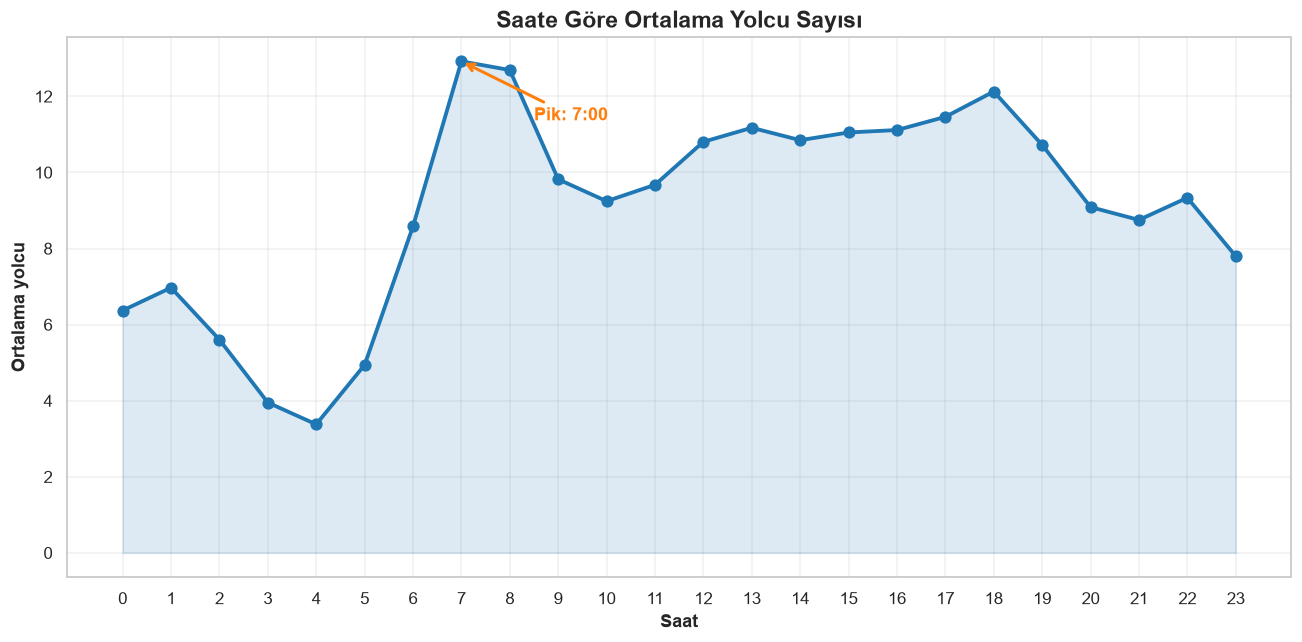

In [12]:
saatlik = otobus.groupby("saat")[S["yolcu"]].mean()
fig, ax = plt.subplots()
ax.plot(saatlik.index, saatlik.values, marker="o", color=ANA_RENK,
        linewidth=2.5, markersize=7, zorder=3)
ax.fill_between(saatlik.index, saatlik.values, alpha=0.15, color=ANA_RENK)
pik = int(saatlik.idxmax())
ax.annotate(f"Pik: {pik}:00", xy=(pik, saatlik.max()),
            xytext=(pik + 1.5, saatlik.max() * 0.88), fontweight="bold", color=VURGU,
            arrowprops=dict(arrowstyle="->", color=VURGU, lw=2))
ax.set_xticks(range(0, 24))
ax.set(title="Saate Göre Ortalama Yolcu Sayısı", xlabel="Saat", ylabel="Ortalama yolcu")
binlik(ax)
plt.tight_layout(); plt.savefig("../figures/01_saatlik_cizgi.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.2 Histogram — Yolcu sayısı dağılımı

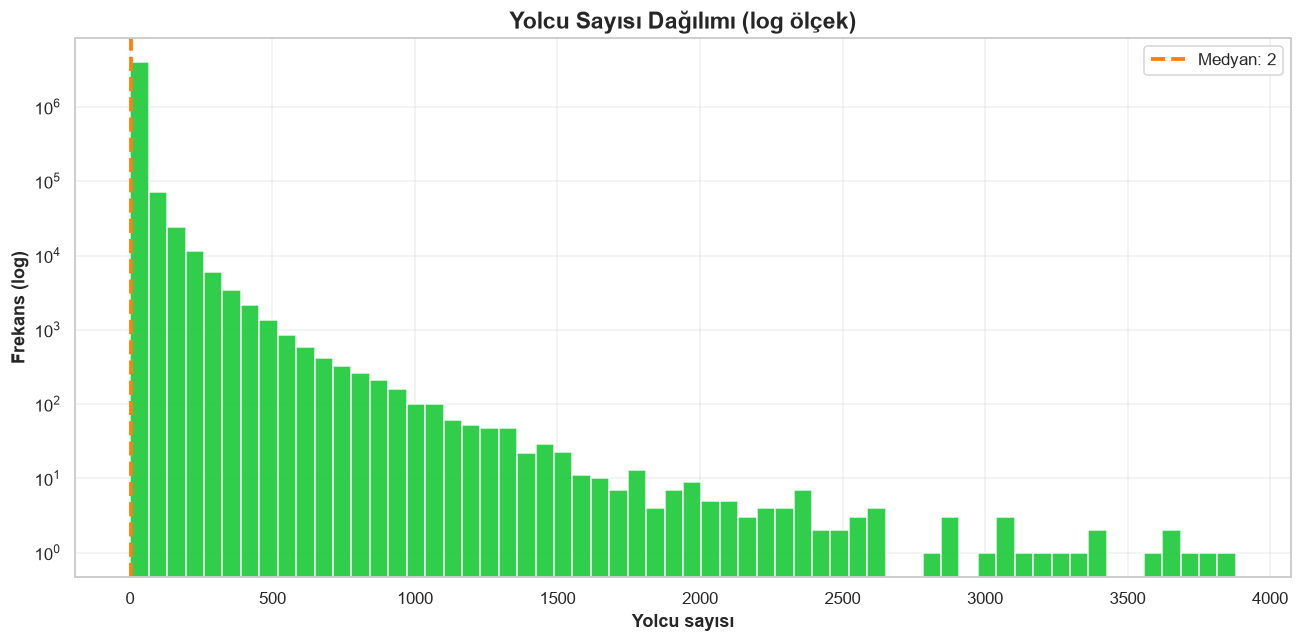

In [13]:
fig, ax = plt.subplots()
ax.hist(otobus[S["yolcu"]], bins=60, color=PALET[2], edgecolor="white", alpha=0.9)
ax.set_yscale("log")                              # aşırı çarpık dağılım için log ölçek
med = otobus[S["yolcu"]].median()
ax.axvline(med, color=VURGU, linestyle="--", linewidth=2.5, label=f"Medyan: {med:.0f}")
ax.set(title="Yolcu Sayısı Dağılımı (log ölçek)",
       xlabel="Yolcu sayısı", ylabel="Frekans (log)")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/02_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.3 Kutu — Aylara göre yolcu (mevsim temsili)

C:\Users\gurka\AppData\Local\Temp\ipykernel_20248\2179759600.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([AYLAR.get(int(t.get_text()), t.get_text()) for t in ax.get_xticklabels()])


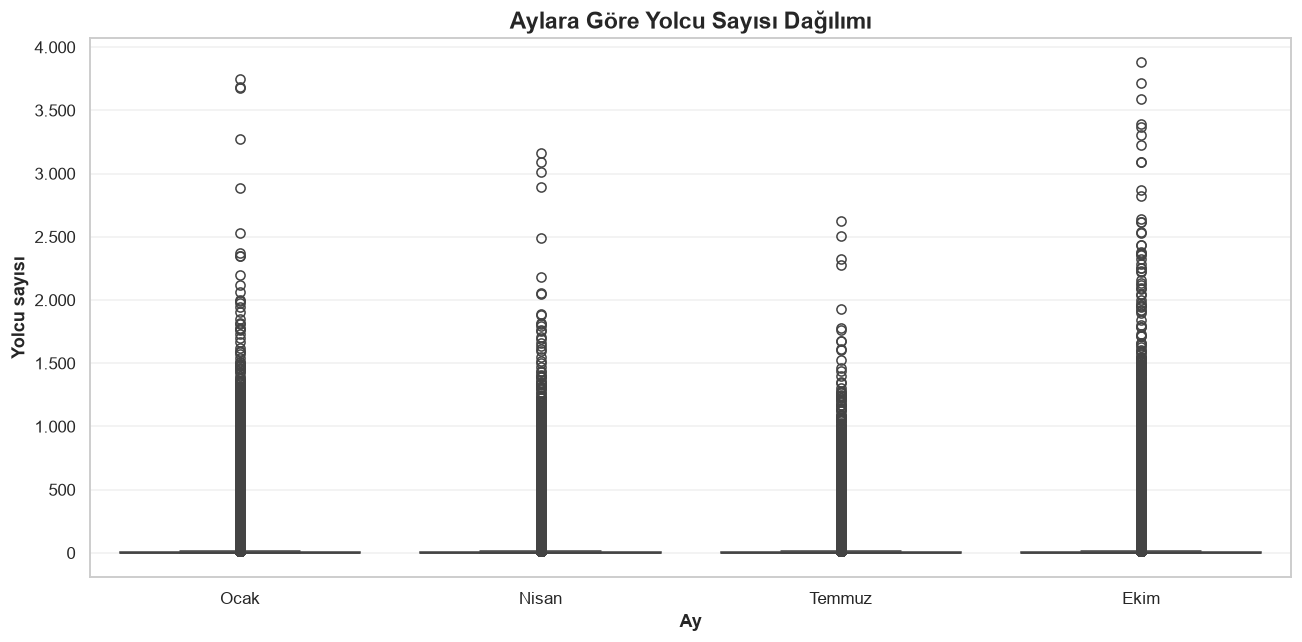

In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=otobus, x="ay", y=S["yolcu"], hue="ay",
            palette="bright", legend=False, ax=ax)
ax.set_xticklabels([AYLAR.get(int(t.get_text()), t.get_text()) for t in ax.get_xticklabels()])
ax.set(title="Aylara Göre Yolcu Sayısı Dağılımı", xlabel="Ay", ylabel="Yolcu sayısı")
binlik(ax)
plt.tight_layout(); plt.savefig("../figures/03_kutu_ay.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.4 Isı haritası — Saat × haftanın günü

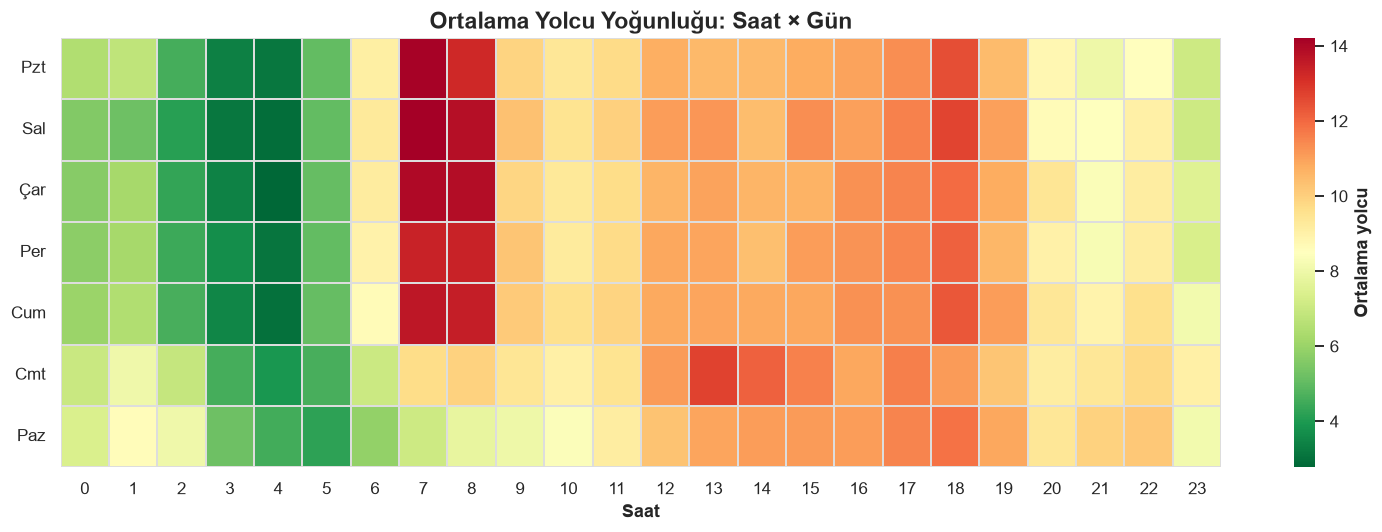

In [15]:
pivot = otobus.pivot_table(index="haftanin_gunu", columns="saat",
                           values=S["yolcu"], aggfunc="mean")
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="RdYlGn_r", ax=ax, linewidths=0.3, linecolor="#dddddd",
            cbar_kws={"label": "Ortalama yolcu"})
ax.set_yticklabels(GUNLER, rotation=0)
ax.set(title="Ortalama Yolcu Yoğunluğu: Saat × Gün", xlabel="Saat", ylabel="")
plt.tight_layout(); plt.savefig("../figures/04_isi_haritasi.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Araştırma Soruları

### Soru 1 — Gün-içi pik saatler; hafta içi vs hafta sonu

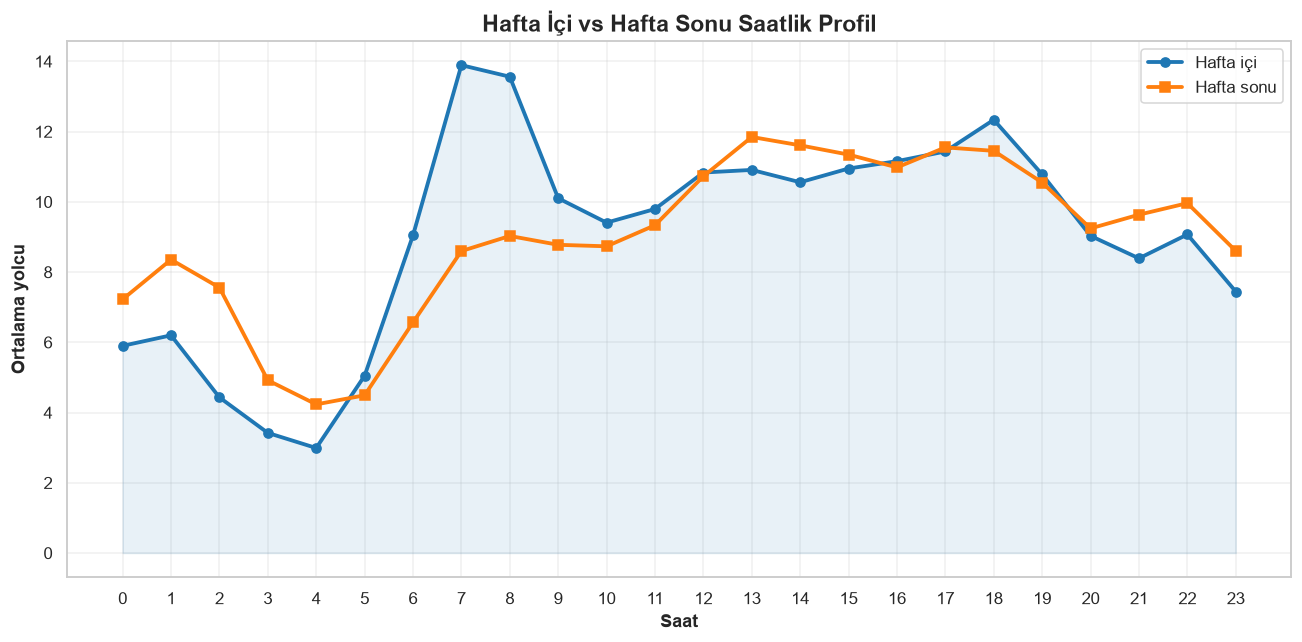

In [16]:
hi = otobus[~otobus["hafta_sonu_mu"]].groupby("saat")[S["yolcu"]].mean()
hs = otobus[otobus["hafta_sonu_mu"]].groupby("saat")[S["yolcu"]].mean()
fig, ax = plt.subplots()
ax.plot(hi.index, hi.values, marker="o", linewidth=2.5, markersize=6, color=ANA_RENK, label="Hafta içi")
ax.plot(hs.index, hs.values, marker="s", linewidth=2.5, markersize=6, color=VURGU, label="Hafta sonu")
ax.fill_between(hi.index, hi.values, alpha=0.10, color=ANA_RENK)
ax.set_xticks(range(0, 24))
ax.set(title="Hafta İçi vs Hafta Sonu Saatlik Profil", xlabel="Saat", ylabel="Ortalama yolcu")
ax.legend(); binlik(ax)
plt.tight_layout(); plt.savefig("../figures/05_haftaici_haftasonu.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (kendi grafiğinle teyit et):** Hafta içi sabah (~08:00) ve akşam (~17–18:00)
çift tepe görülür; bu işe gidiş-dönüş örüntüsüyle uyumludur. Hafta sonu bu tepeler
silinir ve talep güne daha düz yayılır.

### Soru 2 — Mevsimsellik var mı?

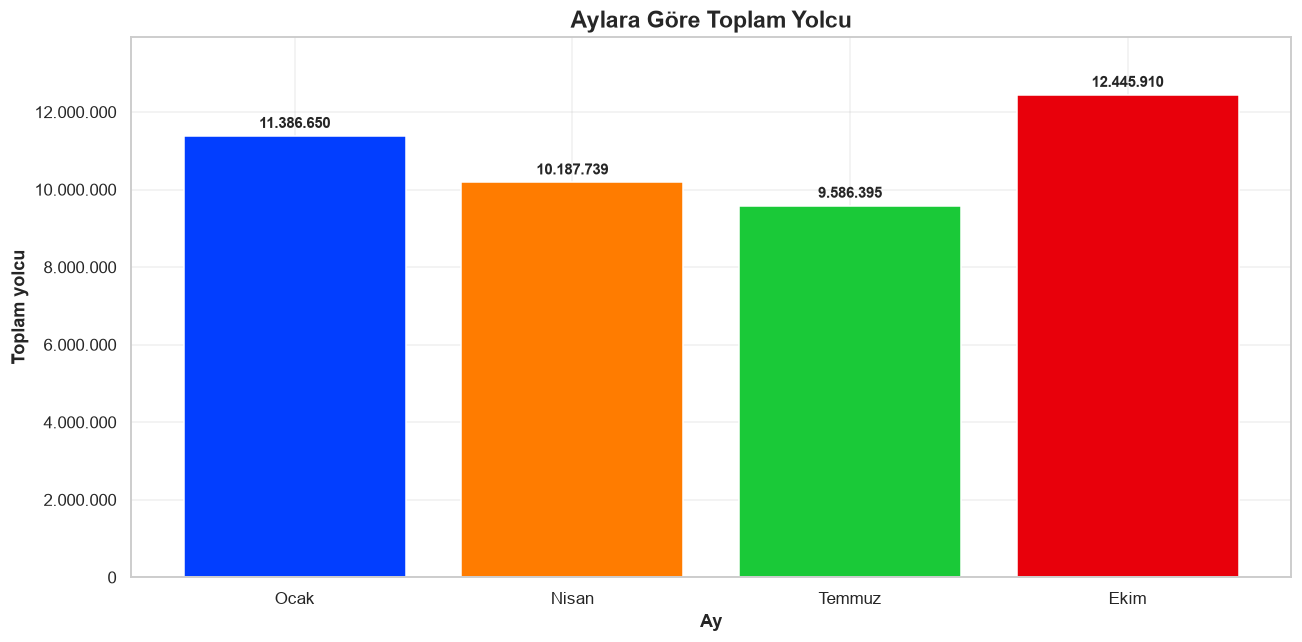

In [17]:
aylik = otobus.groupby("ay")[S["yolcu"]].sum()
fig, ax = plt.subplots()
bars = ax.bar([AYLAR.get(a, a) for a in aylik.index], aylik.values,
              color=PALET[:len(aylik)], edgecolor="white")
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}".replace(",", "."), padding=3, fontsize=10, fontweight="bold")
ax.set(title="Aylara Göre Toplam Yolcu", xlabel="Ay", ylabel="Toplam yolcu")
binlik(ax); ax.margins(y=0.12)
plt.tight_layout(); plt.savefig("../figures/06_aylik_bar.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** Temmuz (yaz / okul tatili) ayında toplam yolcu, diğer aylara
göre belirgin düşer. Bu, eğitim takviminin toplu taşıma talebini sürüklediğini gösterir.

### Ek görsel — Tatil vs normal gün saatlik profil
Modelde kullandığımız `tatil_mi` özelliğinin etkisini görselleştirir: resmî tatillerin talep profili hafta sonuna benzemeli.

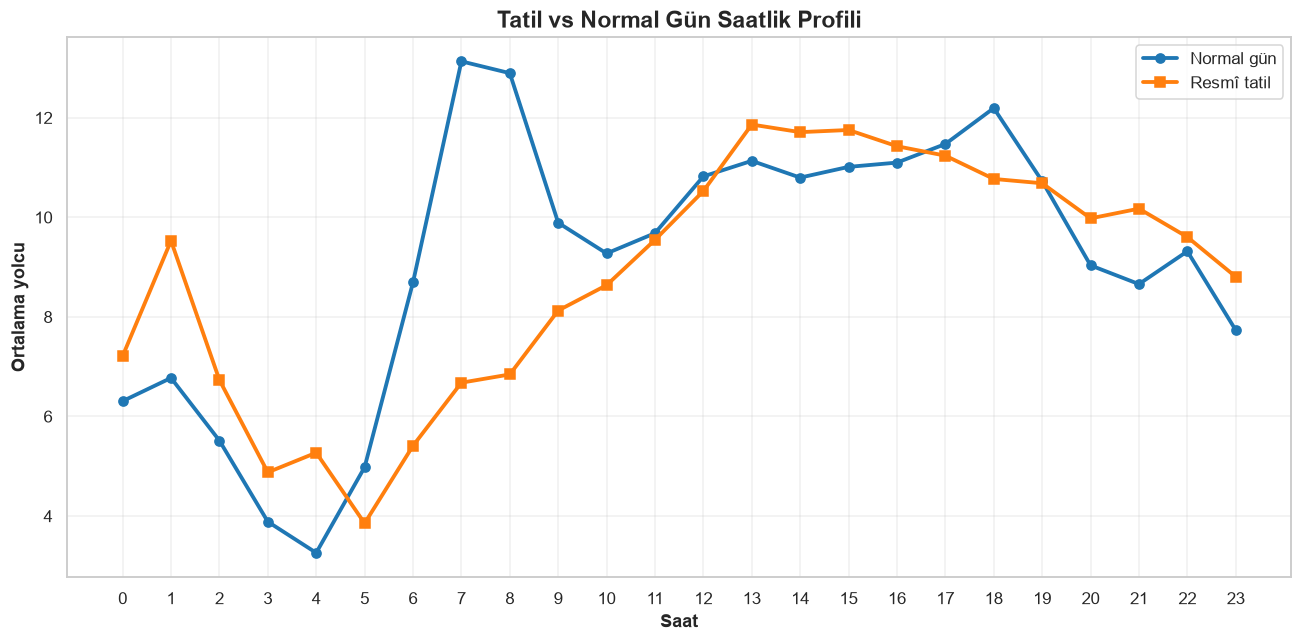

In [18]:
normal = otobus[~otobus["tatil_mi"]].groupby("saat")[S["yolcu"]].mean()
tatil  = otobus[otobus["tatil_mi"]].groupby("saat")[S["yolcu"]].mean()
fig, ax = plt.subplots()
ax.plot(normal.index, normal.values, marker="o", linewidth=2.5, color=ANA_RENK, label="Normal gün")
ax.plot(tatil.index, tatil.values, marker="s", linewidth=2.5, color=VURGU, label="Resmî tatil")
ax.set_xticks(range(0, 24))
ax.set(title="Tatil vs Normal Gün Saatlik Profili", xlabel="Saat", ylabel="Ortalama yolcu")
ax.legend(); binlik(ax)
plt.tight_layout(); plt.savefig("../figures/10_tatil_profil.png", dpi=120, bbox_inches="tight")
plt.show()

### Soru 3 — Az sayıda hat çok mu yolcu taşıyor? (Pareto)

En yoğun 10 hat:
 line_name
34      7760425
34A     1595207
500T     398897
11ÜS     356936
19F      317249
97       317099
10       301033
132M     294921
19S      292946
14ES     281525
Name: number_of_passenger, dtype: int64

İlk %20 hattın toplam yolcudaki payı: %72.8


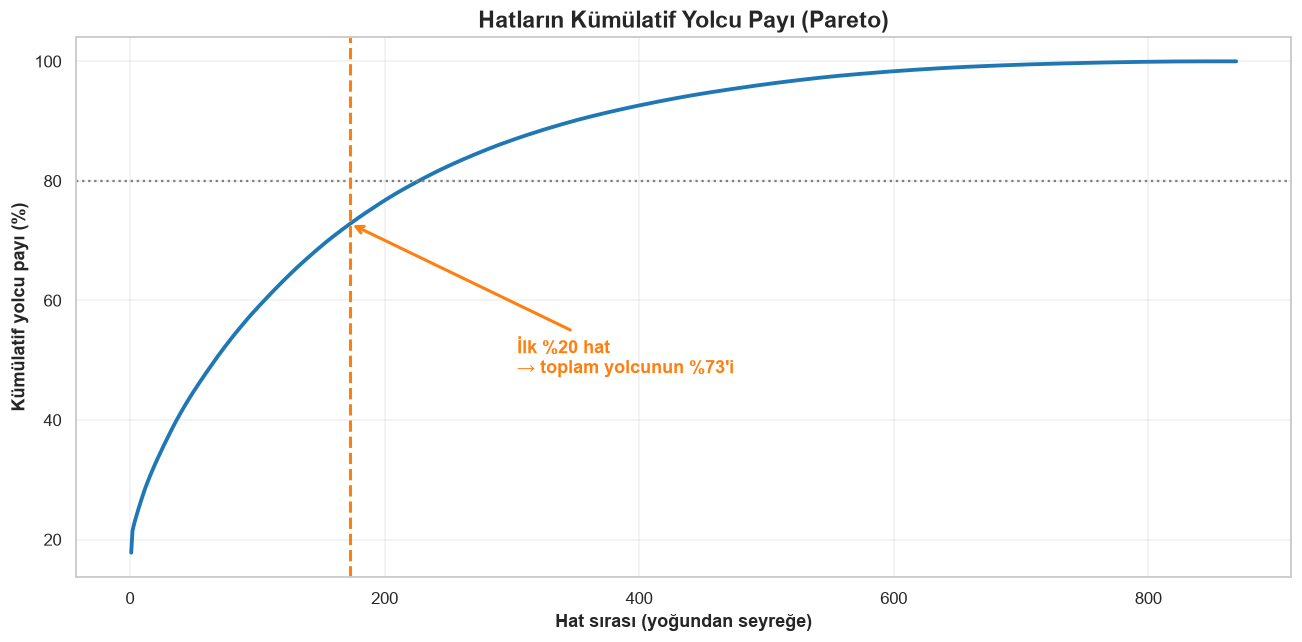

In [19]:
hat = otobus.groupby(S["hat"])[S["yolcu"]].sum().sort_values(ascending=False)
kum = (hat.cumsum() / hat.sum() * 100).reset_index(drop=True)
n20 = max(int(len(hat) * 0.2) - 1, 0)
ilk20_pay = kum.iloc[n20]
print("En yoğun 10 hat:\n", hat.head(10))
print(f"\nİlk %20 hattın toplam yolcudaki payı: %{ilk20_pay:.1f}")

fig, ax = plt.subplots()
ax.plot(range(1, len(kum) + 1), kum.values, color=ANA_RENK, linewidth=2.5)
ax.axhline(80, color="gray", linestyle=":", linewidth=1.5)
ax.axvline(n20 + 1, color=VURGU, linestyle="--", linewidth=2)
ax.annotate(f"İlk %20 hat\n→ toplam yolcunun %{ilk20_pay:.0f}'i",
            xy=(n20 + 1, ilk20_pay), xytext=(len(kum) * 0.35, max(ilk20_pay - 25, 10)),
            fontweight="bold", color=VURGU,
            arrowprops=dict(arrowstyle="->", color=VURGU, lw=2))
ax.set(title="Hatların Kümülatif Yolcu Payı (Pareto)",
       xlabel="Hat sırası (yoğundan seyreğe)", ylabel="Kümülatif yolcu payı (%)")
plt.tight_layout(); plt.savefig("../figures/07_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** Hatların ilk %20'si toplam yolcunun büyük çoğunluğunu taşır
(80-20 / Pareto etkisi). Yani talep az sayıda yoğun koridorda toplanmıştır.

### Soru 4 — Hangi ilçeler en çok yolcu üretiyor?

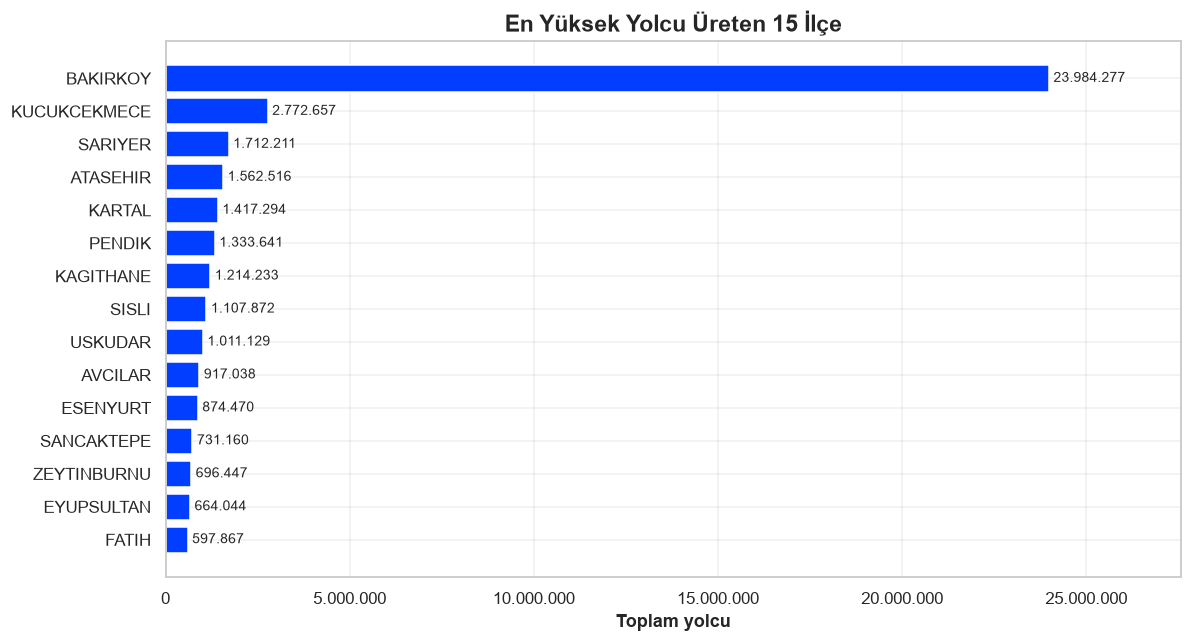

In [20]:
ilce = (otobus.dropna(subset=["town"])
        .groupby("town")[S["yolcu"]].sum()
        .sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(ilce.index[::-1], ilce.values[::-1], color=PALET[0], edgecolor="white")
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}".replace(",", "."), padding=3, fontsize=9)
ax.set(title="En Yüksek Yolcu Üreten 15 İlçe", xlabel="Toplam yolcu", ylabel="")
binlik(ax, "x"); ax.margins(x=0.15)
plt.tight_layout(); plt.savefig("../figures/11_ilce.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** Yolcu talebi belirli merkez ilçelerde yoğunlaşır; bu, Pareto bulgusunun mekânsal karşılığıdır.

### Soru 5 — Ücret tipine göre yolcu dağılımı

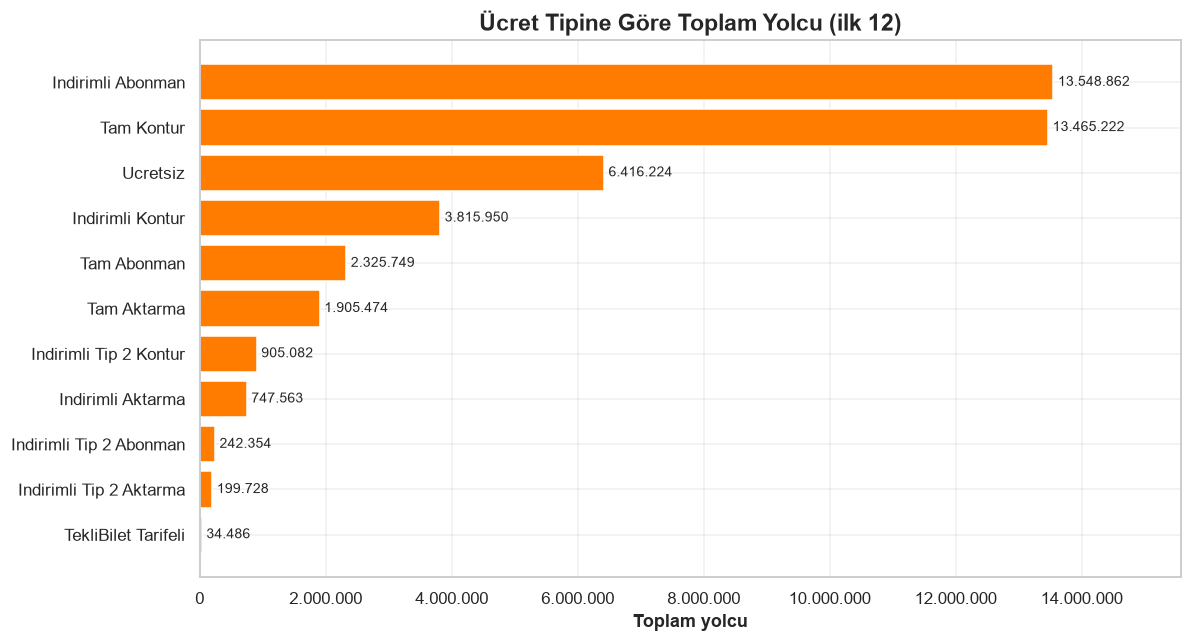

İlk 12 ücret tipinin toplam yolcudaki payı (%):
transaction_type_desc
Indirimli Abonman          31.1
Tam Kontur                 30.9
Ucretsiz                   14.7
Indirimli Kontur            8.8
Tam Abonman                 5.3
Tam Aktarma                 4.4
Indirimli Tip 2 Kontur      2.1
Indirimli Aktarma           1.7
Indirimli Tip 2 Abonman     0.6
Indirimli Tip 2 Aktarma     0.5
TekliBilet Tarifeli         0.1


In [21]:
ucret = (otobus.groupby("transaction_type_desc")[S["yolcu"]].sum()
         .sort_values(ascending=False).head(12))
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(ucret.index[::-1], ucret.values[::-1], color=PALET[1], edgecolor="white")
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}".replace(",", "."), padding=3, fontsize=9)
ax.set(title="Ücret Tipine Göre Toplam Yolcu (ilk 12)", xlabel="Toplam yolcu", ylabel="")
binlik(ax, "x"); ax.margins(x=0.15)
plt.tight_layout(); plt.savefig("../figures/12_ucret_tipi.png", dpi=120, bbox_inches="tight")
plt.show()

pay = (ucret / otobus[S["yolcu"]].sum() * 100).round(1)
print("İlk 12 ücret tipinin toplam yolcudaki payı (%):")
print(pay.to_string())

**Bulgu (teyit et):** Tam ücret ve abonman türleri talebin büyük kısmını oluştururken indirimli/ücretsiz biniş türleri belirli bir pay tutar — bu, yolcu profilinin sosyo-ekonomik bir göstergesidir.

## 6. Modelleme

Hedef: saatlik toplam yolcuyu zaman özelliklerinden tahmin etmek. İki kritik nokta:
- **Zamansal ayrım:** Bu bir zaman serisi olduğu için rastgele bölme gelecekten geçmişe
  bilgi sızdırır (data leakage). Bu yüzden ilk aylarla eğitip son ayla test ediyoruz.
- **Baseline:** Modelin gerçekten değer kattığını göstermek için naif bir tahminciyle
  (her saatin ortalaması) karşılaştırıyoruz.


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Saat-gün-ay-tatil bazında toplam yolcu
model_df = (otobus
            .groupby(["ay", "haftanin_gunu", "saat", "hafta_sonu_mu", "tatil_mi"])[S["yolcu"]]
            .sum().reset_index())

ozellikler = ["ay", "haftanin_gunu", "saat", "hafta_sonu_mu", "tatil_mi"]
X = model_df[ozellikler].astype(int)
y_hedef = model_df[S["yolcu"]]


In [23]:
# --- Zamansal ayrım: son ay (en büyük 'ay' değeri) test, gerisi eğitim ---
test_ay = model_df["ay"].max()
egitim = model_df["ay"] < test_ay
X_train, X_test = X[egitim], X[~egitim]
y_train, y_test = y_hedef[egitim], y_hedef[~egitim]
print(f"Eğitim: {len(X_train)} satır  |  Test (ay={test_ay}): {len(X_test)} satır")


Eğitim: 624 satır  |  Test (ay=10): 192 satır


In [24]:
# --- Baseline: her saatin eğitim ortalaması ---
saat_ort = y_train.groupby(X_train["saat"]).mean()
baseline_pred = X_test["saat"].map(saat_ort).fillna(y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline MAE: {baseline_mae:,.0f}")


Baseline MAE: 27,762


In [25]:
# --- RandomForest ---
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

rf_mae = mean_absolute_error(y_test, pred)
rf_r2  = r2_score(y_test, pred)
iyilesme = (baseline_mae - rf_mae) / baseline_mae * 100
print(f"RandomForest  R²: {rf_r2:.3f}  |  MAE: {rf_mae:,.0f}")
print(f"Baseline'a göre MAE iyileşmesi: %{iyilesme:.1f}")


RandomForest  R²: 0.750  |  MAE: 19,155
Baseline'a göre MAE iyileşmesi: %31.0


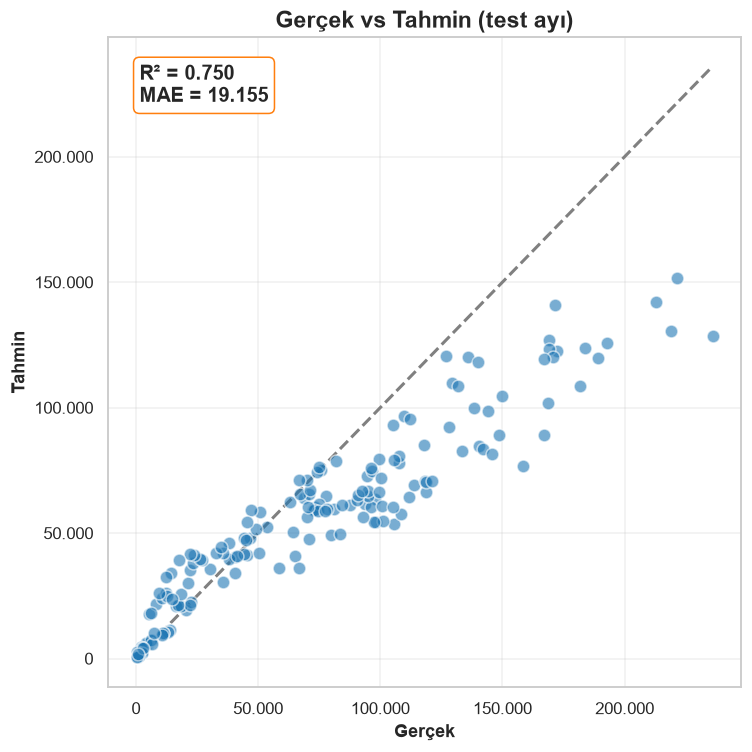

In [26]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, pred, alpha=0.6, color=ANA_RENK, edgecolor="white", s=70, zorder=3)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "--", color="gray", linewidth=2)
ax.text(0.05, 0.90, f"R² = {rf_r2:.3f}\nMAE = {rf_mae:,.0f}".replace(",", "."),
        transform=ax.transAxes, fontweight="bold", fontsize=13,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=VURGU))
ax.set(title="Gerçek vs Tahmin (test ayı)", xlabel="Gerçek", ylabel="Tahmin")
binlik(ax, "x"); binlik(ax, "y")
plt.tight_layout(); plt.savefig("../figures/08_gercek_vs_tahmin.png", dpi=120, bbox_inches="tight")
plt.show()

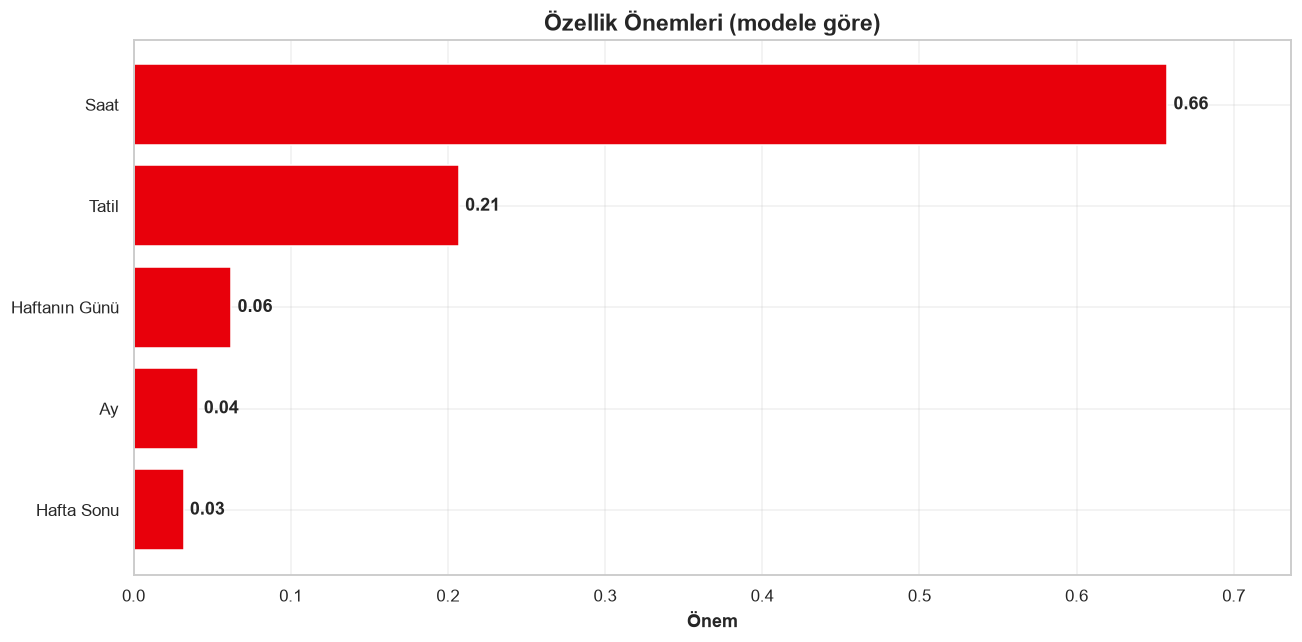

In [27]:
ETIKET = {"ay": "Ay", "haftanin_gunu": "Haftanın Günü", "saat": "Saat",
          "hafta_sonu_mu": "Hafta Sonu", "tatil_mi": "Tatil"}
onem = pd.Series(model.feature_importances_, index=ozellikler).sort_values()
fig, ax = plt.subplots()
bars = ax.barh([ETIKET.get(i, i) for i in onem.index], onem.values, color=PALET[3], edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontweight="bold")
ax.set(title="Özellik Önemleri (modele göre)", xlabel="Önem"); ax.margins(x=0.12)
plt.tight_layout(); plt.savefig("../figures/09_ozellik_onem.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** RandomForest, baseline'ı %X iyileştirdi; demek ki saatin yanı
sıra gün/ay/tatil bilgisi de talebi açıklıyor. Özellik önemlerinde en güçlü değişken
genelde *saat*tir — talebin en çok günün saatine bağlı olduğunu gösterir.

## 6B. Hat Kümeleme (KMeans) — İkinci Model

Regresyona ek olarak ikinci bir teknik: otobüs hatlarını **saatlik talep profillerinin şekline** göre kümeliyoruz. Her hattın profili kendi içinde normalize edilir (büyüklükten bağımsız, sadece şekil), böylece 'işe-gidiş tipi çift tepe' hatlar ile 'gün boyu yoğun' hatlar ayrışır.

In [28]:
from sklearn.cluster import KMeans

# Her hat için saatlik ortalama profil (satır=hat, sütun=saat)
profil = otobus.pivot_table(index=S["hat"], columns="saat",
                            values=S["yolcu"], aggfunc="mean").fillna(0)
profil = profil[profil.sum(axis=1) > 0]

# Şekle göre kümele: her satırı kendi tepe değerine böl (0-1 arası)
profil_norm = profil.div(profil.max(axis=1), axis=0).fillna(0)

k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
kume = km.fit_predict(profil_norm)
profil["kume"] = kume
print("Küme başına hat sayısı:")
print(profil["kume"].value_counts().sort_index().to_string())

Küme başına hat sayısı:
kume
0    111
1    431
2    327


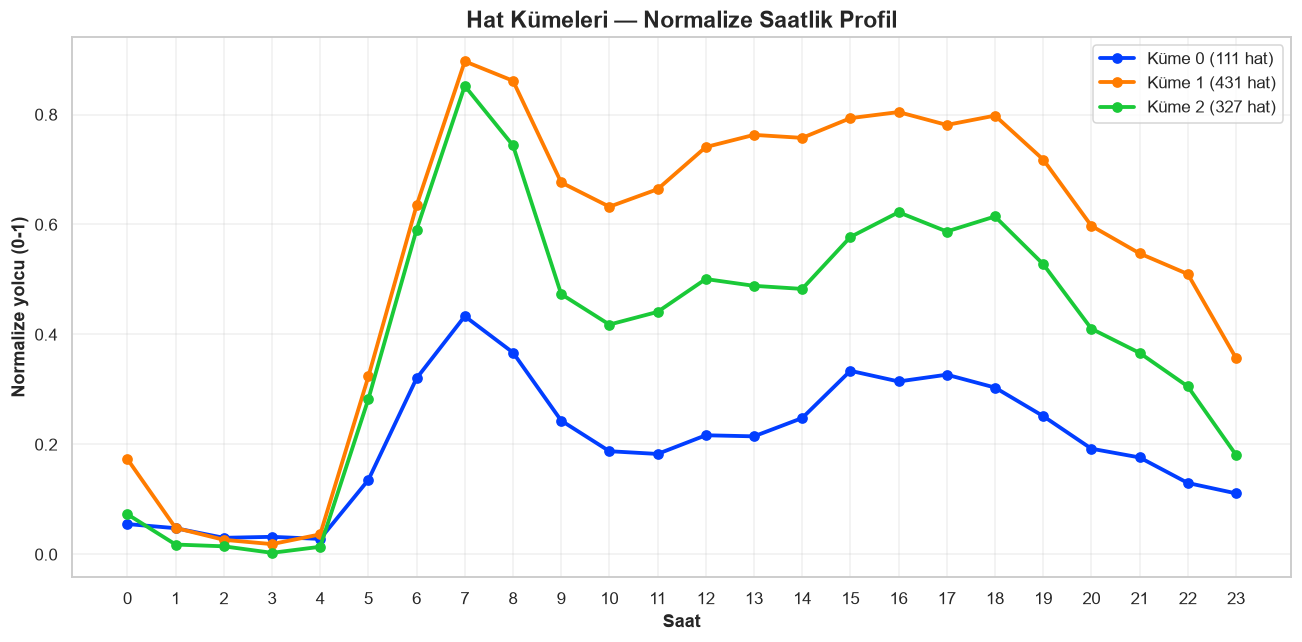

In [29]:
# Küme merkezlerini saatlik profil olarak çiz
fig, ax = plt.subplots()
for c in range(k):
    merkez = profil_norm[profil["kume"] == c].mean()
    ax.plot(merkez.index, merkez.values, marker="o", linewidth=2.5,
            label=f"Küme {c} ({(profil['kume'] == c).sum()} hat)")
ax.set_xticks(range(0, 24))
ax.set(title="Hat Kümeleri — Normalize Saatlik Profil",
       xlabel="Saat", ylabel="Normalize yolcu (0-1)")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/13_hat_kumeleme.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** Kümeler genelde şu üç tipi ortaya çıkarır: (1) sabah+akşam çift tepeli *işe-gidiş hatları*, (2) gün boyu dengeli *gün-içi hatlar*, (3) gece/erken saat ağırlıklı hatlar. Bu, otobüs ağının homojen olmadığını gösterir.

## 7. Sonuç, Yorum ve Sınırlamalar

**Bulgular (tema bağlamında):**
- Soru 1: ... (çift tepe / commute)
- Soru 2: ... (yaz düşüşü)
- Soru 3: ... (Pareto / yoğun koridorlar)
- Model: baseline'a göre iyileşme ve en belirleyici değişken.

**Sınırlamalar:**
- Yalnızca 2023'ün 4 ayı ve tek ulaşım türü (otobüs) kullanıldı.
- Zamansal ayrım uygulandı; yine de tek aylık test penceresi dardır.
- Hava durumu, etkinlikler gibi dış değişkenler dahil edilmedi.

**Öğrenilenler (vibe coding öz-değerlendirme):**
- Yapay zekânın ürettiği koddan neyi olduğu gibi aldım, neyi değiştirdim?
- Hangi noktada AI'nın çıktısını düzelttim / doğruladım? (örn. veri sızıntısı fark edildi)
- Sürecin en çok zaman alan kısmı neydi?
